In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")


In [4]:
url = "/content/winequality-red.csv"
df = pd.read_csv(url)
df.shape
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
df["target"] = (df["quality"] >= 7).astype(int)

df = df.drop(columns=["quality"])

print(df["target"].value_counts())

target
0    1382
1     217
Name: count, dtype: int64


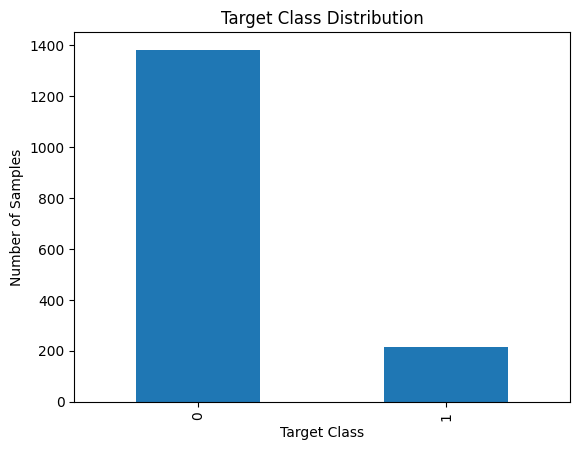

In [9]:
df["target"].value_counts().plot(kind="bar")

plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.show()

In [10]:
X = df.drop(columns=["target"])
y = df["target"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1599, 11)
Target: (1599,)


In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1119, 11)
Validation set: (240, 11)
Test set: (240, 11)


In [12]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

gb_pipeline = Pipeline([
    ("model", GradientBoostingClassifier(random_state=42))
])

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(random_state=42))
])

In [13]:
rf_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [14]:
gb_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_split": [2, 5]
}

In [15]:
svm_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto"]
}

In [16]:
grid_models = {
    "Random Forest": (rf_pipeline, rf_grid),
    "Gradient Boosting": (gb_pipeline, gb_grid),
    "SVM": (svm_pipeline, svm_grid)
}

grid_results = {}
grid_best_models = {}

for name, (pipeline, param_grid) in grid_models.items():

    print("\n" + "=" * 60)
    print(f"GRID SEARCH: {name}")
    print("=" * 60)

    start_time = time.time()

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    elapsed_time = time.time() - start_time

    best_model = grid_search.best_estimator_

    grid_best_models[name] = best_model

    validation_predictions = best_model.predict(X_val)

    validation_f1 = f1_score(
        y_val,
        validation_predictions,
        zero_division=0
    )

    grid_results[name] = {
        "Best Parameters": grid_search.best_params_,
        "Best CV F1": grid_search.best_score_,
        "Validation F1": validation_f1,
        "Training Time": elapsed_time
    }

    print("\nBest Parameters:")
    print(grid_search.best_params_)

    print(f"Best CV F1: {grid_search.best_score_:.4f}")
    print(f"Validation F1: {validation_f1:.4f}")
    print(f"Training Time: {elapsed_time:.2f} seconds")


GRID SEARCH: Random Forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1: 0.5001
Validation F1: 0.6923
Training Time: 58.22 seconds

GRID SEARCH: Gradient Boosting
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV F1: 0.5208
Validation F1: 0.7037
Training Time: 59.19 seconds

GRID SEARCH: SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters:
{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV F1: 0.4511
Validation F1: 0.6538
Training Time: 2.78 seconds


In [17]:
rf_random = {
    "model__n_estimators": [50, 100, 150, 200, 250, 300],
    "model__max_depth": [None, 5, 10, 15, 20, 25],
    "model__min_samples_split": [2, 3, 5, 7, 10],
    "model__min_samples_leaf": [1, 2, 3, 4]
}

gb_random = {
    "model__n_estimators": [50, 100, 150, 200, 250],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 3, 5, 7]
}

svm_random = {
    "svc__C": [0.01, 0.1, 1, 10, 50, 100],
    "svc__kernel": ["linear", "rbf", "poly"],
    "svc__gamma": ["scale", "auto", 0.001, 0.01, 0.1]
}

In [20]:
random_models = {
    "Random Forest": (rf_pipeline, rf_random),
    "Gradient Boosting": (gb_pipeline, gb_random),
    "SVM": (svm_pipeline, svm_random)
}

random_results = {}
random_best_models = {}

for name, (pipeline, param_distributions) in random_models.items():

    print("\n" + "=" * 60)
    print(f"RANDOMIZED SEARCH: {name}")
    print("=" * 60)

    start_time = time.time()

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=20,
        scoring="f1",
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    random_search.fit(X_train, y_train)

    elapsed_time = time.time() - start_time

    best_model = random_search.best_estimator_

    random_best_models[name] = best_model

    validation_predictions = best_model.predict(X_val)

    validation_f1 = f1_score(
        y_val,
        validation_predictions,
        zero_division=0
    )

    random_results[name] = {
        "Best Parameters": random_search.best_params_,
        "Best CV F1": random_search.best_score_,
        "Validation F1": validation_f1,
        "Training Time": elapsed_time
    }

    print("\nBest Parameters:")
    print(random_search.best_params_)

    print(f"Best CV F1: {random_search.best_score_:.4f}")
    print(f"Validation F1: {validation_f1:.4f}")
    print(f"Training Time: {elapsed_time:.2f} seconds")


RANDOMIZED SEARCH: Random Forest
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 15}
Best CV F1: 0.4593
Validation F1: 0.7037
Training Time: 46.16 seconds

RANDOMIZED SEARCH: Gradient Boosting
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'model__n_estimators': 250, 'model__min_samples_split': 5, 'model__max_depth': 5, 'model__learning_rate': 0.15}
Best CV F1: 0.5282
Validation F1: 0.6909
Training Time: 58.56 seconds

RANDOMIZED SEARCH: SVM
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'svc__kernel': 'poly', 'svc__gamma': 'auto', 'svc__C': 50}
Best CV F1: 0.4892
Validation F1: 0.5818
Training Time: 71.85 seconds


In [22]:
grid_results_df = pd.DataFrame(grid_results).T
random_results_df = pd.DataFrame(random_results).T

print("GridSearch Results:")
display(grid_results_df)

print("\nRandomizedSearch Results:")
display(random_results_df)

GridSearch Results:


,Best Parameters,Best CV F1,Validation F1,Training Time
Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.500074,0.692308,58.219494
Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",0.520815,0.703704,59.185848
SVM,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...",0.451148,0.653846,2.777746



RandomizedSearch Results:


,Best Parameters,Best CV F1,Validation F1,Training Time
Random Forest,"{'model__n_estimators': 50, 'model__min_sample...",0.459294,0.703704,46.157218
Gradient Boosting,"{'model__n_estimators': 250, 'model__min_sampl...",0.528218,0.690909,58.559509
SVM,"{'svc__kernel': 'poly', 'svc__gamma': 'auto', ...",0.489172,0.581818,71.84975


In [23]:
comparison = pd.DataFrame({
    "GridSearch CV F1": grid_results_df["Best CV F1"],
    "GridSearch Validation F1": grid_results_df["Validation F1"],
    "GridSearch Time": grid_results_df["Training Time"],
    "RandomSearch CV F1": random_results_df["Best CV F1"],
    "RandomSearch Validation F1": random_results_df["Validation F1"],
    "RandomSearch Time": random_results_df["Training Time"]
})

comparison.round(4)

,GridSearch CV F1,GridSearch Validation F1,GridSearch Time,RandomSearch CV F1,RandomSearch Validation F1,RandomSearch Time
Random Forest,0.500074,0.692308,58.219494,0.459294,0.703704,46.157218
Gradient Boosting,0.520815,0.703704,59.185848,0.528218,0.690909,58.559509
SVM,0.451148,0.653846,2.777746,0.489172,0.581818,71.84975


In [24]:
test_results = {}

for name, model in grid_best_models.items():

    test_predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, test_predictions)
    precision = precision_score(
        y_test,
        test_predictions,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        test_predictions,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        test_predictions,
        zero_division=0
    )

    test_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


Random Forest
Accuracy : 0.9292
Precision: 0.8947
Recall   : 0.5312
F1 Score : 0.6667

Gradient Boosting
Accuracy : 0.9125
Precision: 0.7037
Recall   : 0.5938
F1 Score : 0.6441

SVM
Accuracy : 0.8833
Precision: 0.6000
Recall   : 0.3750
F1 Score : 0.4615


In [25]:
test_results_df = pd.DataFrame(test_results).T

print("Final Test Set Performance:")
display(test_results_df.round(4))

Final Test Set Performance:


,Accuracy,Precision,Recall,F1 Score
Random Forest,0.9292,0.8947,0.5312,0.6667
Gradient Boosting,0.9125,0.7037,0.5938,0.6441
SVM,0.8833,0.6000,0.3750,0.4615


In [26]:
for name, model in grid_best_models.items():

    predictions = model.predict(X_test)

    print("\n" + "=" * 70)
    print(f"CLASSIFICATION REPORT — {name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Not Good", "Good"],
            zero_division=0
        )
    )


CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

    Not Good       0.93      0.99      0.96       208
        Good       0.89      0.53      0.67        32

    accuracy                           0.93       240
   macro avg       0.91      0.76      0.81       240
weighted avg       0.93      0.93      0.92       240


CLASSIFICATION REPORT — Gradient Boosting
              precision    recall  f1-score   support

    Not Good       0.94      0.96      0.95       208
        Good       0.70      0.59      0.64        32

    accuracy                           0.91       240
   macro avg       0.82      0.78      0.80       240
weighted avg       0.91      0.91      0.91       240


CLASSIFICATION REPORT — SVM
              precision    recall  f1-score   support

    Not Good       0.91      0.96      0.93       208
        Good       0.60      0.38      0.46        32

    accuracy                           0.88       240
   macro avg     

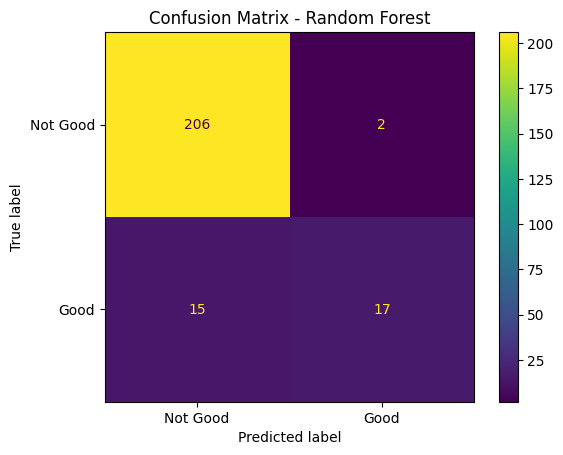

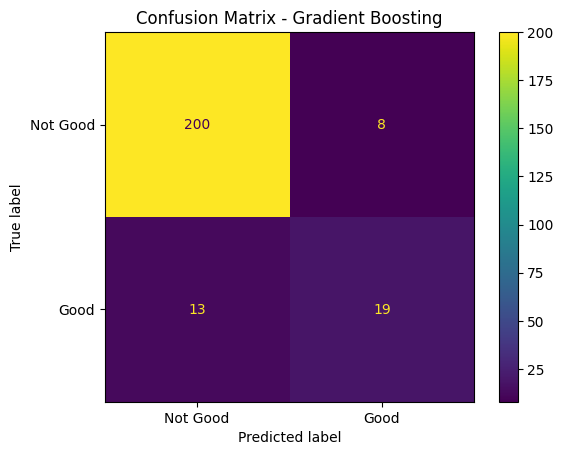

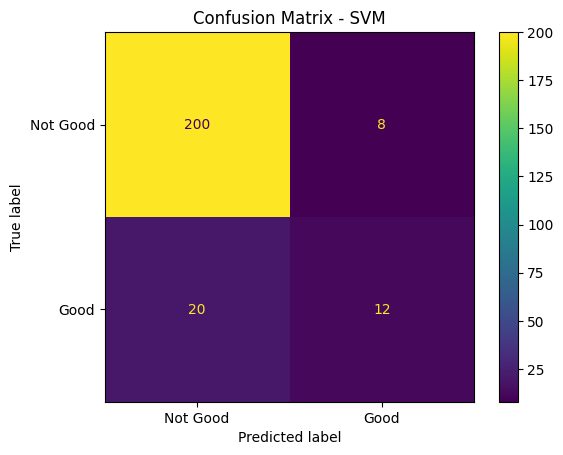

In [27]:
for name, model in grid_best_models.items():

    predictions = model.predict(X_test)

    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Good", "Good"]
    )

    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [28]:
best_model_name = test_results_df["F1 Score"].idxmax()

print("Best Model:", best_model_name)
print(
    "Best Test F1 Score:",
    round(test_results_df.loc[best_model_name, "F1 Score"], 4)
)

Best Model: Random Forest
Best Test F1 Score: 0.6667


In [29]:
print("Best Model:", best_model_name)
print("\nBest Hyperparameters:")

if best_model_name == "Random Forest":
    print(grid_results["Random Forest"]["Best Parameters"])

elif best_model_name == "Gradient Boosting":
    print(grid_results["Gradient Boosting"]["Best Parameters"])

elif best_model_name == "SVM":
    print(grid_results["SVM"]["Best Parameters"])

Best Model: Random Forest

Best Hyperparameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
